# SALES ANALYSIS - DATA SCIENCE PROJECT

## SALES ANALYSIS PROJECT - AAL (AUSTRALIA APPAREL LIMITED)

**---------------------------------------------------------------------------------------------------------------------------------------**
# *IMPORT ALL REQUIRED LIBRARIES*

In [208]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

 # *LOAD THE DATASET*

In [370]:
df = pd.read_csv("AusApparalSales4thQrt2020.csv")
df

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500


------------------------------------------------------------------------------------------------------------
 # *DATA CLEANING AND WRANGLING*

In [31]:
# Convert 'Date' column to datetime format

df['Date'] = pd.to_datetime(df['Date'], format="%yy-%mm-%dd")
df.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500


In [301]:
# Check for missing values
missing_values = df.isna().sum()
print("Missing values in each column:\n", missing_values)

# Handle missing values (dropping in this case)
df = df.dropna()
df.head(4)

Missing values in each column:
 Date          0
Time          0
State         0
Group         0
Unit          0
Sales         0
Sales_Norm    0
Unit_Norm     0
Week          0
Month         0
Quarter       0
dtype: int64


,Date,Time,State,Group,Unit,Sales,Sales_Norm,Unit_Norm,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238,40,10,4
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238,40,10,4
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746,40,10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349,40,10,4


In [35]:
# Normalize 'Sales' and 'Unit' columns using Min-Max Scaling

scaler = MinMaxScaler()
df[['Sales_Norm', 'Unit_Norm']] = scaler.fit_transform(df[['Sales', 'Unit']])
df.head()

,Date,Time,State,Group,Unit,Sales,Sales_Norm,Unit_Norm
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873


-------------------------------------------------------------------------------------------------------------
 # *DATA ANALYSIS*

- **Descriptive statistics for Sales and Unit columns**

In [43]:
sales_stats = df['Sales'].describe()
unit_stats = df['Unit'].describe()
print("Sales Statistics:\n", sales_stats)
print("--------------------------------")
print("Unit Statistics:\n", unit_stats)

Sales Statistics:
 count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64
--------------------------------
Unit Statistics:
 count    7560.000000
mean       18.005423
std        12.901403
min         2.000000
25%         8.000000
50%        14.000000
75%        26.000000
max        65.000000
Name: Unit, dtype: float64


- **Additional descriptive statistics**

In [247]:
# mode of sales
sales_mode = stats.mode(df['Sales'],keepdims = True).mode[0]
print(f"Mode for sales: {sales_mode}")

#modes of unit
unit_mode = stats.mode(df['Unit'],keepdims = True).mode[0]
print(f"Mode for units: {unit_mode}")

Mode for sales: 22500
Mode for units: 9


- **Grouping Data by State and Summing Sales**

In [349]:
 # This is for getting top-performing regions
state_sales = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
print(state_sales) 

  State      Sales
5   VIC  105565000
0   NSW   74970000
3    SA   58857500
2   QLD   33417500
4   TAS   22760000
1    NT   22580000
6    WA   22152500


- ***Q1. Identify states with highest and lowest revenues***

- The State with Highest Revenue is VIC with revenue of - $105565000
  
- The State with Lowest Revenue is  WA with revenue of - $22152500

- ***Q2. Suggested Sales Programs for Low Revenue States i.e., for WA:***

Suggested Sales Programs for  WA:
- 1. We need to introduce promotional discounts for this state to enhance the revenue
- 2. We have to do some Targeted marketing campaigns
- 3. We need to Expand product varieties with some attractive discounts
- 4. We can also Improve the local distribution channels through which the revenue can increase
- 5. We need to focus on age groups and time of highest sale and arrange giveaway and random prizes with some offers for them

- **Grouping Data by Demographic Group (Kids, Women, Men, Seniors)**

In [49]:
# Determines which customer segment (Kids, Men, Women, Seniors) generates the most revenue.
group_sales = df.groupby('Group')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
print(group_sales)

      Group     Sales
1       Men  85750000
3     Women  85442500
0      Kids  85072500
2   Seniors  84037500


- ***Q3. Identify groups with highest & lowest sales***

In [292]:
highest_sales_group = group_sales.iloc[0]
lowest_sales_group = group_sales.iloc[-1]
print(f"Highest Sales Group: {highest_sales_group['Group']} with {highest_sales_group['Sales']} sales")
print(f"Lowest Sales Group: {lowest_sales_group['Group']} with {lowest_sales_group['Sales']} sales")

Highest Sales Group:  Men with 85750000 sales
Lowest Sales Group:  Seniors with 84037500 sales


- **Grouping Data by Time of Day**

In [352]:
#Helps analyze sales trends over different time periods.
time_sales = df.groupby('Time')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
print(time_sales) 

         Time      Sales
2     Morning  114207500
0   Afternoon  114007500
1     Evening  112087500


----------------------------------------------------------------------------------------------------------
## *TIME BASED ANALYSIS*

- **Extract Week, Month, and Quarter from Date**

In [69]:
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

- **Aggregate sales by Week, Month, and Quarter**

In [257]:
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index()
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
quarterly_sales = df.groupby('Quarter')['Sales'].sum().reset_index()

# Generate summary reports
print("---------------------------------")
print("Weekly Sales Summary:")
print(weekly_sales)
print("---------------------------------")
print("\nMonthly Sales Summary:")
print(monthly_sales)
print("---------------------------------")
print("\nQuarterly Sales Summary:")
print(quarterly_sales)

---------------------------------
Weekly Sales Summary:
    Week     Sales
0     40  15045000
1     41  27002500
2     42  26640000
3     43  26815000
4     44  21807500
5     45  20865000
6     46  21172500
7     47  21112500
8     48  21477500
9     49  29622500
10    50  31525000
11    51  31655000
12    52  31770000
13    53  13792500
---------------------------------

Monthly Sales Summary:
   Month      Sales
0     10  114290000
1     11   90682500
2     12  135330000
---------------------------------

Quarterly Sales Summary:
   Quarter      Sales
0        4  340302500


--------------------------------------
# *DATA VISUALISATION*

In [85]:
df

,Date,Time,State,Group,Unit,Sales,Sales_Norm,Unit_Norm,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238,40,10,4
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238,40,10,4
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746,40,10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349,40,10,4
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873,40,10,4
...,...,...,...,...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,14,35000,0.190476,0.190476,53,12,4
7556,2020-12-30,Evening,TAS,Kids,15,37500,0.206349,0.206349,53,12,4
7557,2020-12-30,Evening,TAS,Men,15,37500,0.206349,0.206349,53,12,4
7558,2020-12-30,Evening,TAS,Women,11,27500,0.142857,0.142857,53,12,4


- **State-wise Sales Analysis for Different Demographic Groups**

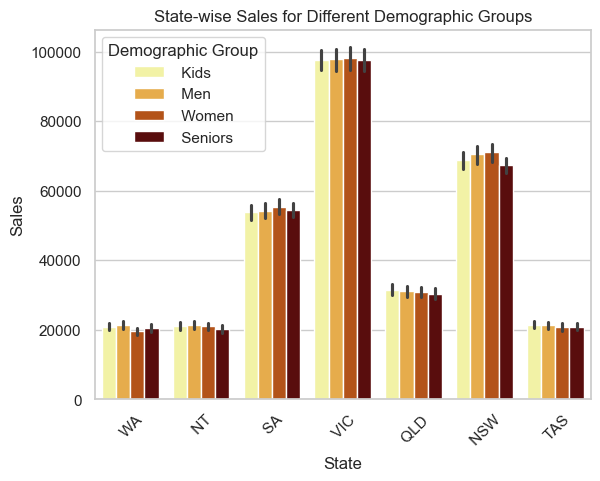

In [391]:
#plot the bar graph
sns.barplot(x='State', y='Sales', hue='Group', data=df, palette='afmhot_r')

#add title and legend
plt.title("State-wise Sales for Different Demographic Groups")
plt.xticks(rotation=45)  # Rotate for better readability
plt.legend(title="Demographic Group")

#show the graph
plt.show()

- **Group-wise Sales Bar Chart Across Various States**

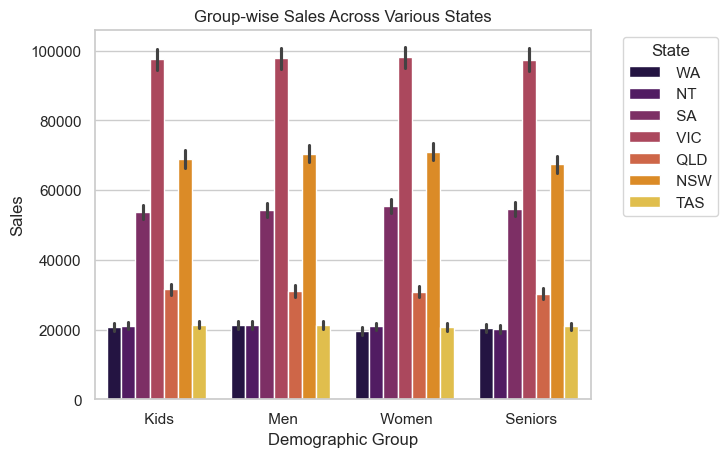

In [415]:
#plot bar plot for groupwise sales
sns.barplot(x='Group', y='Sales', hue='State', data=df, palette='inferno')

# add title and labels and legend
plt.title("Group-wise Sales Across Various States")
plt.xlabel("Demographic Group")
plt.ylabel("Sales")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')

#show the graph
plt.show()

- **Sales by Time of Day Bar Chart**

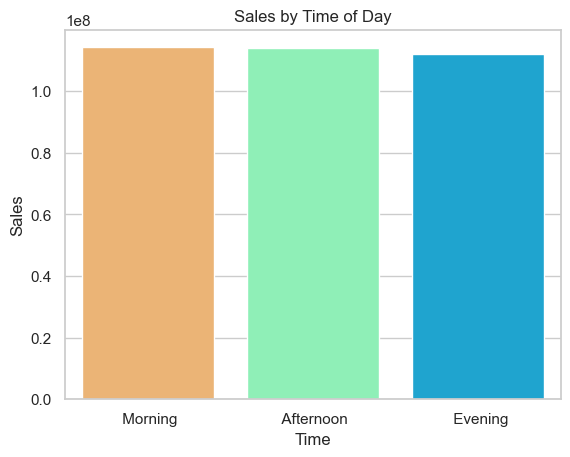

In [401]:
# creating barplot using seaborn
sns.barplot(x='Time', y='Sales', data=time_sales, hue='Time', palette='rainbow_r')

# adding the title to the plot
plt.title("Sales by Time of Day")

# showing the interactive graph
plt.show()

- **Sales Distribution Box Plot**

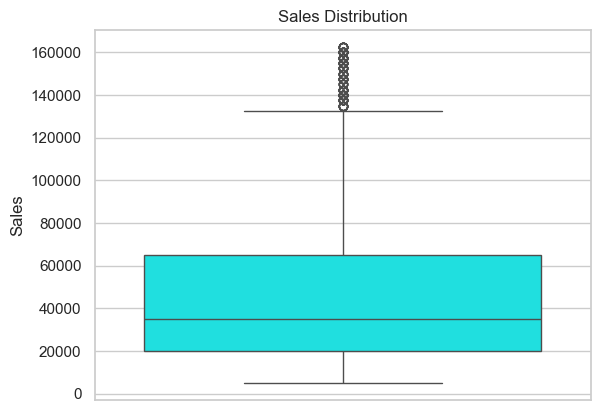

In [408]:
sns.boxplot(y=df['Sales'], color = 'aqua')
plt.title("Sales Distribution")
plt.show()


- **Correlation Heatmap**

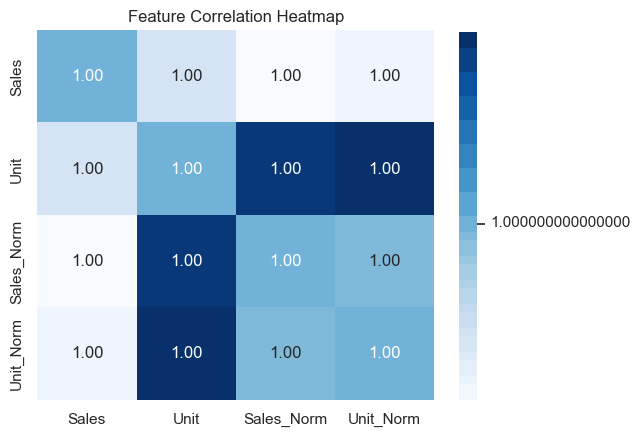

In [315]:
sns.heatmap(df[['Sales', 'Unit', 'Sales_Norm', 'Unit_Norm']].corr(), annot=True, cmap='Blues', fmt='0.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

# *TIME BASED TRENDS*

- **Weekly Sales Trend**

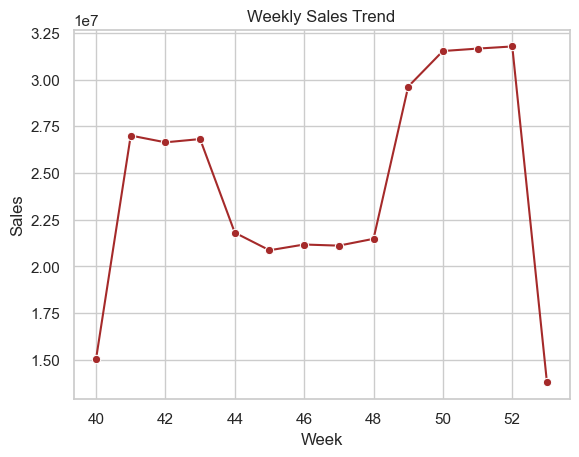

In [183]:
# plotting line graph using seaborn
sns.lineplot(x='Week', y='Sales', data=weekly_sales, marker="o", color="brown")

# add a title
plt.title("Weekly Sales Trend")

#Show the interactive graph
plt.show()

- **Monthly Sales Trend**

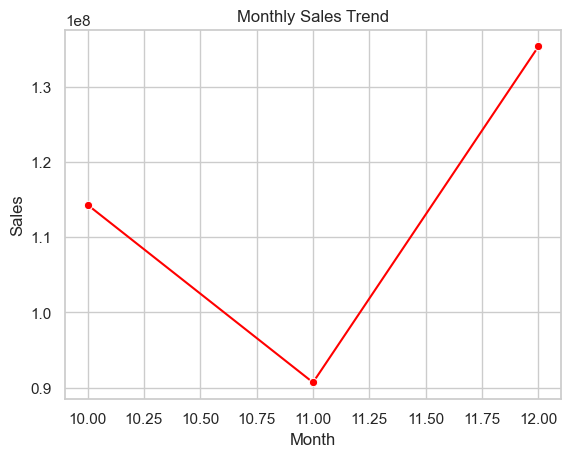

In [406]:
# plotting line graph using seaborn
sns.lineplot(x='Month', y='Sales', data=monthly_sales, marker="o", color="red")

# add a title
plt.title("Monthly Sales Trend")

# show the interactive graph
plt.show()

- **Quarterly Sales Trend**

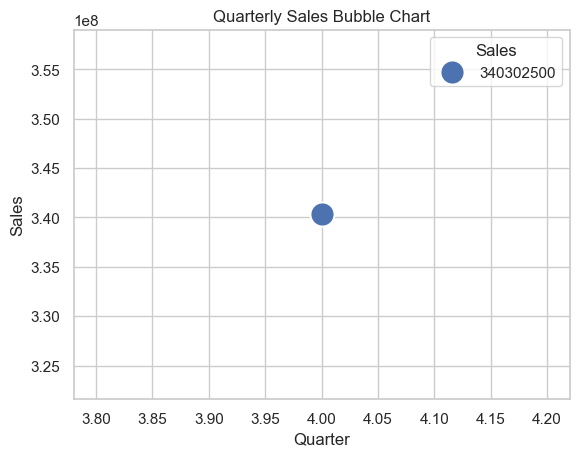

In [345]:
sns.scatterplot(x='Quarter', y='Sales', size='Sales', data=quarterly_sales, alpha=1, sizes=(300, 200))
plt.title("Quarterly Sales Bubble Chart")
plt.show()

- **Seaborn provides aesthetically appealing and customizable plots.**

- **Matplotlib allows fine-tuned control over plot elements.**

- **Both libraries support categorical and numerical data visualization effectively.**

- **Box Plot helps visualize the distribution of sales data. Identifies outliers and variability in sales.**